# End-to-End Fine-Tuning Pipeline

Full pipeline in one notebook:
1. **Configure** — pick feedback environment config, seeds, agent paths
2. **Collect corrections** — run base agent episodes, record smart-agent disagreements
3. **Visualize corrections** — inspect sample frames with base vs smart actions
4. **Fine-tune** — behavioral cloning on corrections with KL regularization
5. **Evaluate** — compare base, smart, and fine-tuned agents on the same feedback levels

In [4]:
%load_ext autoreload
%autoreload 2

import os, sys, copy, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Ensure project root is importable
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import gym
import procgen  # registers envs
from stable_baselines3 import PPO
from dpu_clf import (
    get_config_by_index, BASE_ENV_CONFIG, ENV_CONFIG_DEFINITIONS,
    draw_full_path_with_doors, record_frames_with_doors,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

ACTION_NAMES = {0: "left", 1: "stay", 2: "right", 3: "throw"}

print("Imports OK")
print(f"Available env configs: {list(ENV_CONFIG_DEFINITIONS.keys())}")
for idx, cfg in ENV_CONFIG_DEFINITIONS.items():
    print(f"  Config {idx}: {cfg['option_name']}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK
Available env configs: [0, 1, 2, 3, 4, 5, 6]
  Config 0: no_walls
  Config 1: walls_food
  Config 2: walls_junk
  Config 3: walls_doors
  Config 4: walls_doors_fruits
  Config 5: no_walls_junk
  Config 6: walls_narrow


## 1. Pipeline Configuration

Define which environment config/seeds to use for feedback, which agents serve as base and smart (user-proxy), and fine-tuning hyperparameters.

In [22]:
# ===================== PIPELINE CONFIGURATION =====================

# --- Feedback environment settings ---
FEEDBACK_CONFIG = 1          # env config index (0-6, see list above)
FEEDBACK_SEEDS = range(10, 14) #list(range(50))  # env seeds to collect corrections on
FEEDBACK_LEVELS = range(10, 14) #list(range(50)) # start_level per episode (same length as seeds)
NUM_EPISODES = len(FEEDBACK_LEVELS)

# --- Agent paths ---
BASE_AGENT_PATH  = str(PROJECT_ROOT / "models/fruitbot/20260116-074523_easy/ppo_final")   # no_doors_collect_all
SMART_AGENT_PATH = str(PROJECT_ROOT / "models/fruitbot/20251231-174002_easy/ppo_final")    # open_doors_fruits_only

# --- Correction settings ---
ONLY_DISAGREEMENTS = True   # True = only keep steps where base ≠ smart

# --- Fine-tuning hyperparameters ---
FT_EPOCHS     = 25
FT_BATCH_SIZE = 16
FT_LR         = 1e-3
FT_BC_WEIGHT  = 1.0    # behavioral cloning weight
FT_KL_WEIGHT  = 0      # KL regularization weight (prevents forgetting)
FREEZE_CNN    = True    # True = freeze CNN backbone, only train MLP head + action_net

# --- Data Augmentation ---
# With ~10-20 corrections, augmentation is critical to avoid overfitting
# Each original sample produces AUG_REPEATS augmented copies per epoch
AUGMENT_DATA        = False  # Enable/disable augmentation
AUG_REPEATS         = 10    # How many augmented copies per sample (10-20 → 100-400 effective samples)
AUG_COLOR_JITTER    = False  # Random brightness/contrast/saturation shifts
AUG_RANDOM_CROP     = True  # Random crop + resize back (simulates slight camera shifts)
AUG_HORIZONTAL_FLIP = True  # Flip left/right (⚠️ also flips actions — set True only if handled)
AUG_GAUSSIAN_NOISE  = False # Add small gaussian noise to pixels
AUG_CUTOUT          = True  # Random rectangular cutout (occlusion robustness)

# --- Load agents ---
print("Loading agents...")
base_agent  = PPO.load(BASE_AGENT_PATH)
smart_agent = PPO.load(SMART_AGENT_PATH)
print(f"  ✓ Base agent  : no_doors_collect_all")
print(f"  ✓ Smart agent : open_doors_fruits_only")
print(f"\nFeedback environment: config={FEEDBACK_CONFIG} "
      f"({ENV_CONFIG_DEFINITIONS[FEEDBACK_CONFIG]['option_name']}), "
      f"{NUM_EPISODES} episodes")

Loading agents...
  ✓ Base agent  : no_doors_collect_all
  ✓ Smart agent : open_doors_fruits_only

Feedback environment: config=1 (walls_food), 4 episodes


c:\Users\matan\anaconda3\envs\procgen_env_clone\lib\site-packages\stable_baselines3\common\save_util.py:435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.loa

## 2. Collect Corrections (Base Agent vs Smart Agent)

Run the base agent on each feedback episode. At every timestep, also query the smart agent for its action on the same observation. This produces correction triplets `(obs, base_action, smart_action)`.

In [23]:
from generate_corrections import make_env, collect_episode


# ---- Run collection ----
print(f"Collecting corrections: {NUM_EPISODES} episodes on config {FEEDBACK_CONFIG}")
print("=" * 70)

all_obs, all_base, all_user = [], [], []
all_rewards, all_dones, all_episode_ids = [], [], []
all_frames_by_episode = []  # keep frames for visualization

total_steps = 0
total_disagreements = 0
per_episode_stats = []

for ep_idx in range(NUM_EPISODES):
    seed = FEEDBACK_SEEDS[ep_idx]
    level = FEEDBACK_LEVELS[ep_idx]
    
    env = make_env(FEEDBACK_CONFIG, seed=seed, start_level=level)
    data = collect_episode(env, base_agent, smart_agent)
    env.close()
    
    n_steps = len(data["base_actions"])
    disagree_mask = data["base_actions"] != data["user_actions"]
    n_disagree = int(disagree_mask.sum())
    
    total_steps += n_steps
    total_disagreements += n_disagree
    
    per_episode_stats.append({
        'episode': ep_idx, 'seed': seed, 'level': level,
        'steps': n_steps, 'disagreements': n_disagree,
        'disagree_pct': 100 * n_disagree / max(n_steps, 1),
        'total_reward': float(data["rewards"].sum()),
    })
    
    # Keep frames for visualization (only disagree frames if filtering)
    ep_frames_info = []
    for t in range(n_steps):
        if disagree_mask[t]:
            ep_frames_info.append({
                'episode': ep_idx, 'step': t,
                'frame': data["observations"][t],
                'base_action': int(data["base_actions"][t]),
                'smart_action': int(data["user_actions"][t]),
                'reward': float(data["rewards"][t]),
            })
    all_frames_by_episode.append(ep_frames_info)
    
    if ONLY_DISAGREEMENTS:
        if n_disagree > 0:
            all_obs.append(data["observations"][disagree_mask])
            all_base.append(data["base_actions"][disagree_mask])
            all_user.append(data["user_actions"][disagree_mask])
            all_rewards.append(data["rewards"][disagree_mask])
            all_dones.append(data["dones"][disagree_mask])
            all_episode_ids.append(np.full(n_disagree, ep_idx, dtype=np.int64))
    else:
        all_obs.append(data["observations"])
        all_base.append(data["base_actions"])
        all_user.append(data["user_actions"])
        all_rewards.append(data["rewards"])
        all_dones.append(data["dones"])
        all_episode_ids.append(np.full(n_steps, ep_idx, dtype=np.int64))
    
    if (ep_idx + 1) % 10 == 0 or ep_idx == 0:
        print(f"  Episode {ep_idx+1:3d}/{NUM_EPISODES} | "
              f"steps={n_steps:3d} | disagree={n_disagree:3d} ({100*n_disagree/max(n_steps,1):.1f}%)")

# Concatenate
corrections_obs = np.concatenate(all_obs, axis=0)
corrections_base = np.concatenate(all_base, axis=0)
corrections_user = np.concatenate(all_user, axis=0)
corrections_rewards = np.concatenate(all_rewards, axis=0)
corrections_dones = np.concatenate(all_dones, axis=0)
corrections_episode_ids = np.concatenate(all_episode_ids, axis=0)

# Flatten all disagreement frames for easy access
all_disagree_frames = [f for ep in all_frames_by_episode for f in ep]

print(f"\n{'='*70}")
print(f"COLLECTION SUMMARY")
print(f"{'='*70}")
print(f"  Total episodes:           {NUM_EPISODES}")
print(f"  Total timesteps:          {total_steps}")
print(f"  Total corrections:        {total_disagreements} "
      f"({100*total_disagreements/max(total_steps,1):.1f}% of all steps)")
print(f"  Saved training samples:   {len(corrections_base)}")
print(f"  Observations shape:       {corrections_obs.shape}")

# Action distribution
base_dist = Counter(corrections_base.tolist())
user_dist = Counter(corrections_user.tolist())
print(f"\n  Base agent action dist (in saved data):")
for a in sorted(base_dist):
    print(f"    {ACTION_NAMES.get(a, a):>6s}: {base_dist[a]:>5d} ({100*base_dist[a]/len(corrections_base):.1f}%)")
print(f"  Smart agent action dist (in saved data):")
for a in sorted(user_dist):
    print(f"    {ACTION_NAMES.get(a, a):>6s}: {user_dist[a]:>5d} ({100*user_dist[a]/len(corrections_user):.1f}%)")

df_episodes = pd.DataFrame(per_episode_stats)
print(f"\n  Per-episode disagreement rate: "
      f"mean={df_episodes['disagree_pct'].mean():.1f}%, "
      f"std={df_episodes['disagree_pct'].std():.1f}%, "
      f"min={df_episodes['disagree_pct'].min():.1f}%, "
      f"max={df_episodes['disagree_pct'].max():.1f}%")

Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
  Episode   1/4 | steps=132 | disagree= 95 (72.0%)
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo

COLLECTION SUMMARY
  Total episodes:           4
  Total timesteps:          528
  Total corrections:        346 (65.5% of all steps)
  Saved training samples:   346
  Observations shape:       (346, 64, 64, 3)

  Base agent action dist (in saved data):
      left:    62 (17.9%)
      stay:    88 (25.4%)
     right:    88 (25.4%)
     throw:   108 (31.2%)
  Smart agent action dist (in saved data):
      left:   178 (51.4%)
      stay:    53 (15.3%)
     right:    

## 3. Visualize Corrections

Inspect sample frames where the base and smart agents disagree. Each image shows the observation along with the base agent's action vs the smart agent's (correction) action.

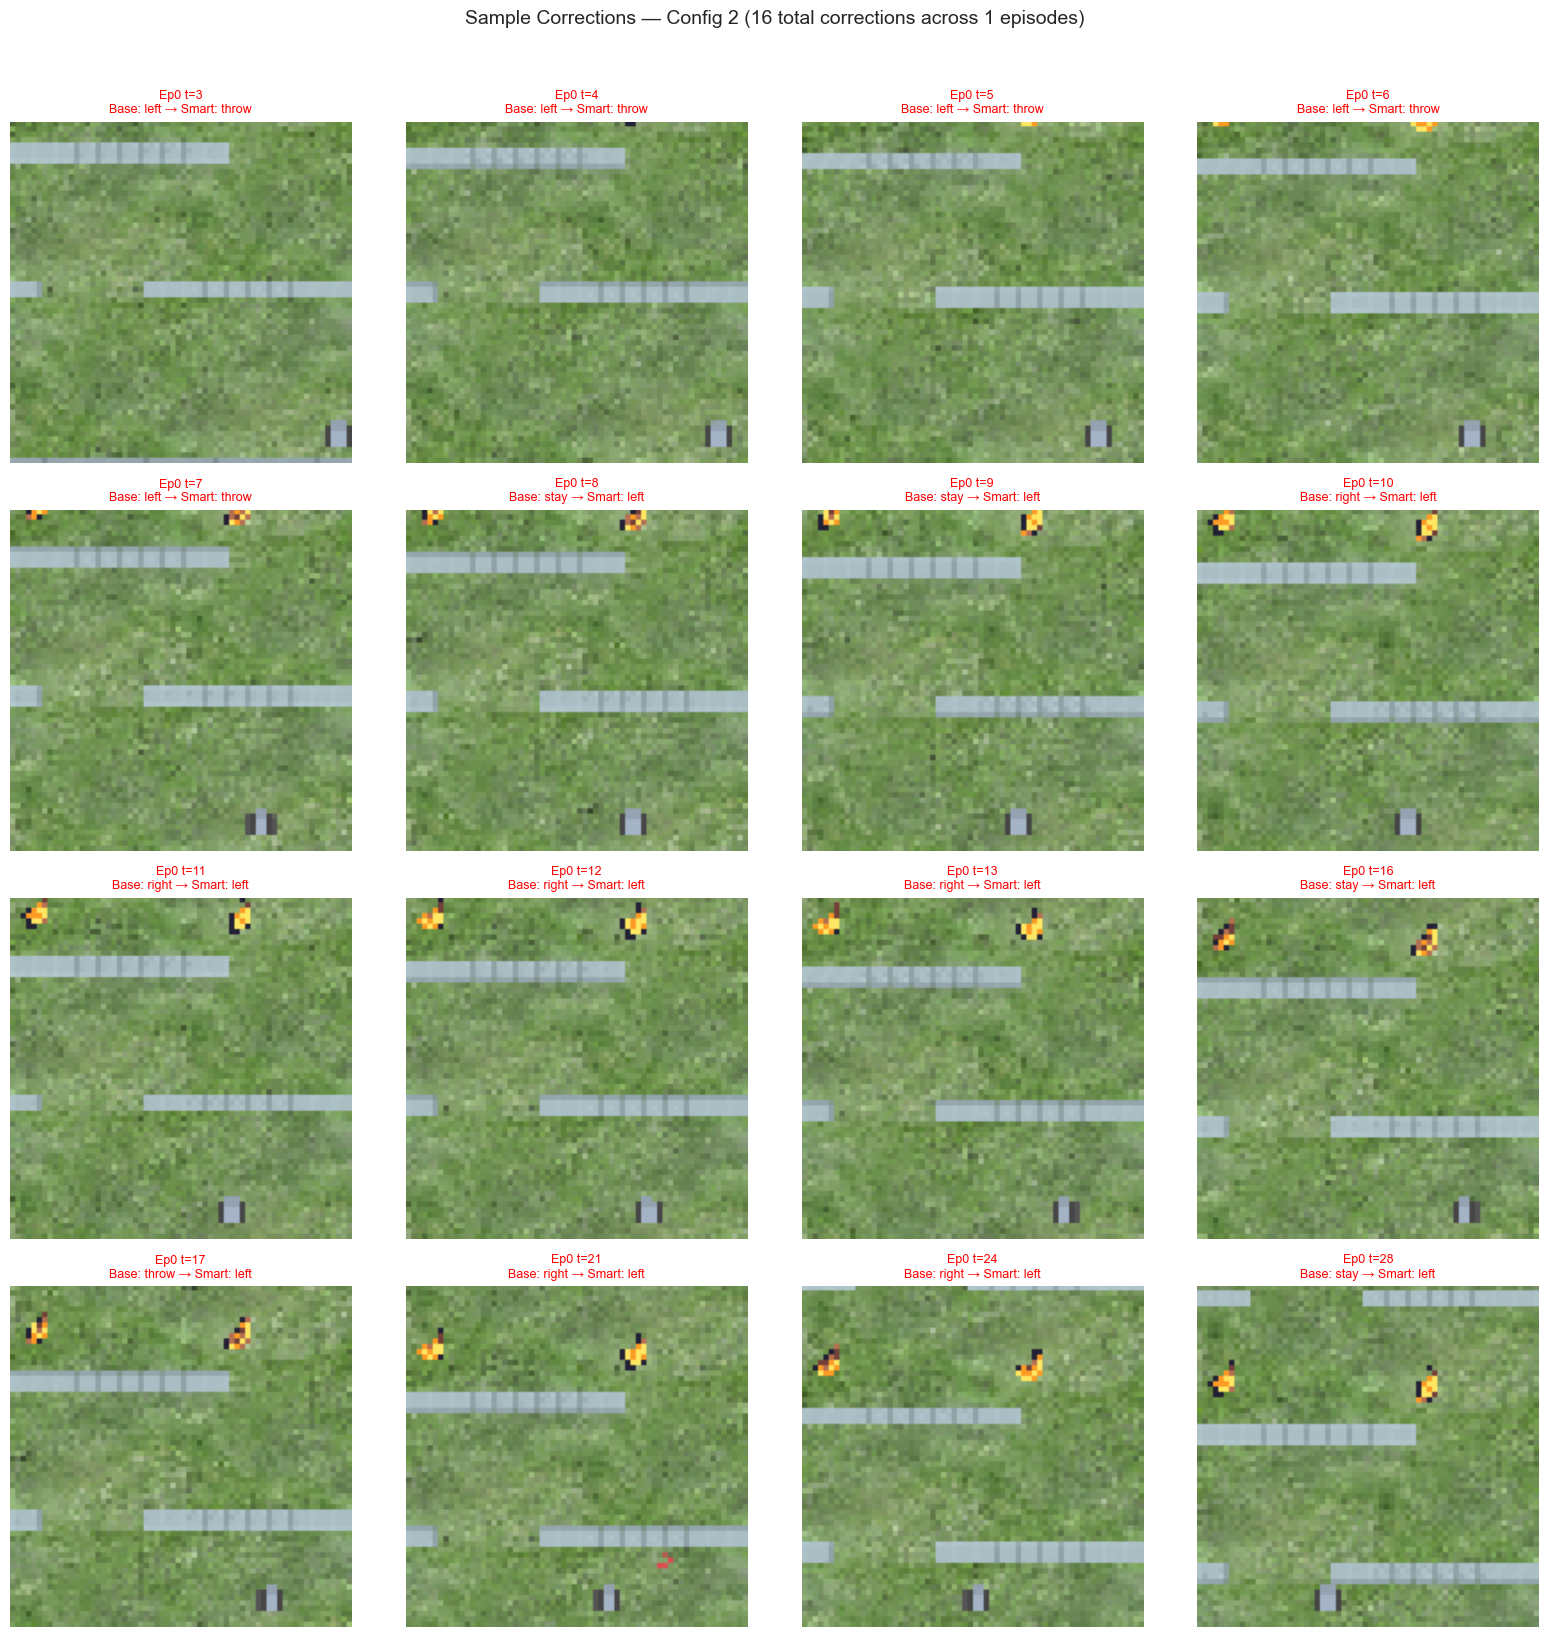

In [4]:
# --- Correction samples visualization ---
NUM_SAMPLES = 16  # how many correction frames to show

# Pick samples spread across episodes
sample_indices = np.linspace(0, len(all_disagree_frames) - 1, min(NUM_SAMPLES, len(all_disagree_frames)), dtype=int)
samples = [all_disagree_frames[i] for i in sample_indices]

ncols = 4
nrows = (len(samples) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.atleast_2d(axes)

for idx, ax in enumerate(axes.flat):
    if idx < len(samples):
        s = samples[idx]
        frame_img = Image.fromarray(s['frame']).resize((128, 128), Image.NEAREST)
        ax.imshow(frame_img)
        base_a = ACTION_NAMES.get(s['base_action'], str(s['base_action']))
        smart_a = ACTION_NAMES.get(s['smart_action'], str(s['smart_action']))
        ax.set_title(f"Ep{s['episode']} t={s['step']}\n"
                     f"Base: {base_a} → Smart: {smart_a}",
                     fontsize=9, color='red' if base_a != smart_a else 'black')
        ax.axis('off')
    else:
        ax.axis('off')

fig.suptitle(f"Sample Corrections — Config {FEEDBACK_CONFIG} "
             f"({total_disagreements} total corrections across {NUM_EPISODES} episodes)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Fine-Tune the Base Agent

Key techniques for effective fine-tuning with very few corrections (~10-20):
- **Freeze CNN** — only train MLP head + action_net (~10K params vs ~1.5M), making small data much more impactful
- **Data augmentation** — multiply 20 samples → 200+ with color jitter, crops, noise, cutout
- **CE loss** — push the policy towards the smart agent's actions
- **KL loss** (optional) — keep the policy close to the original base agent

In [24]:
# --- Build PyTorch dataset from in-memory corrections ---
import torchvision.transforms as T
import random


class CorrectionDataset(Dataset):
    """Dataset of (obs, user_action, base_action) with optional augmentation.
    
    When augment=True, each original sample is repeated `aug_repeats` times
    with random transforms, effectively multiplying the dataset size.
    """
    def __init__(self, obs, user_actions, base_actions, *,
                 augment=False, aug_repeats=10,
                 color_jitter=True, random_crop=True,
                 horizontal_flip=False, gaussian_noise=True, cutout=True):
        self.observations = torch.from_numpy(obs)        # (N,H,W,C) uint8
        self.user_actions = torch.from_numpy(user_actions).long()
        self.base_actions = torch.from_numpy(base_actions).long()
        self.n_original = len(self.user_actions)
        self.augment = augment
        self.aug_repeats = aug_repeats if augment else 1
        self.horizontal_flip = horizontal_flip
        self.gaussian_noise = gaussian_noise
        self.cutout = cutout
        
        # Build torchvision transform pipeline (operates on CHW float tensors)
        transforms = []
        if augment and color_jitter:
            transforms.append(T.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05))
        if augment and random_crop:
            h, w = obs.shape[1], obs.shape[2]
            transforms.append(T.RandomResizedCrop(
                size=(h, w), scale=(0.80, 1.0), ratio=(0.95, 1.05)))
        self.transform = T.Compose(transforms) if transforms else None
        
        print(f"  Dataset: {self.n_original} original samples"
              f"{f' × {self.aug_repeats} repeats = {len(self)} effective' if augment else ''}")
        if augment:
            active = [n for n, v in [('color_jitter', color_jitter), ('random_crop', random_crop),
                                      ('h_flip', horizontal_flip), ('noise', gaussian_noise),
                                      ('cutout', cutout)] if v]
            print(f"  Augmentations: {', '.join(active)}")
    
    def __len__(self):
        return self.n_original * self.aug_repeats
    
    def __getitem__(self, idx):
        real_idx = idx % self.n_original
        obs = self.observations[real_idx]        # (H,W,C) uint8
        user_act = self.user_actions[real_idx]
        base_act = self.base_actions[real_idx]
        
        if self.augment and idx >= self.n_original:
            # Convert to CHW float for transforms, then back to HWC uint8
            obs_chw = obs.permute(2, 0, 1).float() / 255.0   # (C,H,W) [0,1]
            
            if self.transform is not None:
                obs_chw = self.transform(obs_chw)
            
            # Horizontal flip (must also swap left↔right actions)
            if self.horizontal_flip and random.random() < 0.5:
                obs_chw = obs_chw.flip(-1)
                if user_act.item() == 0:
                    user_act = torch.tensor(2, dtype=torch.long)
                elif user_act.item() == 2:
                    user_act = torch.tensor(0, dtype=torch.long)
                if base_act.item() == 0:
                    base_act = torch.tensor(2, dtype=torch.long)
                elif base_act.item() == 2:
                    base_act = torch.tensor(0, dtype=torch.long)
            
            # Gaussian noise
            if self.gaussian_noise:
                noise = torch.randn_like(obs_chw) * 0.02
                obs_chw = (obs_chw + noise).clamp(0, 1)
            
            # Random cutout (zero out a random rectangle)
            if self.cutout:
                _, h, w = obs_chw.shape
                cut_h = random.randint(h // 10, h // 5)
                cut_w = random.randint(w // 10, w // 5)
                y = random.randint(0, h - cut_h)
                x = random.randint(0, w - cut_w)
                obs_chw[:, y:y+cut_h, x:x+cut_w] = 0
            
            # Back to HWC uint8
            obs = (obs_chw.permute(1, 2, 0) * 255).byte()
        
        return obs, user_act, base_act


def preprocess_obs(obs_batch, device):
    """NHWC uint8 -> NCHW float32 [0,1] (mirrors SB3 CnnPolicy)."""
    x = obs_batch.float().to(device) / 255.0
    return x.permute(0, 3, 1, 2)


def finetune(model, dataset, *, epochs, batch_size, lr, bc_weight, kl_weight,
             freeze_cnn=True, device=None):
    """Fine-tune PPO policy with BC + KL regularization.
    
    If freeze_cnn=True, only the MLP extractor and action head are trained.
    This drastically reduces trainable parameters (~10K vs ~1.5M) and makes
    small correction datasets much more effective.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    dev = torch.device(device)
    
    model.policy.to(dev)
    
    # ---- Freeze CNN backbone ----
    if freeze_cnn:
        for p in model.policy.features_extractor.parameters():
            p.requires_grad = False
        model.policy.features_extractor.eval()
        trainable = [p for p in model.policy.parameters() if p.requires_grad]
        n_frozen = sum(p.numel() for p in model.policy.features_extractor.parameters())
        n_trainable = sum(p.numel() for p in trainable)
        print(f"  🧊 CNN FROZEN: {n_frozen:,} params frozen, {n_trainable:,} trainable")
    else:
        trainable = list(model.policy.parameters())
        n_total = sum(p.numel() for p in trainable)
        print(f"  Full model trainable: {n_total:,} params")
    
    # Frozen copy for KL
    frozen_policy = copy.deepcopy(model.policy)
    frozen_policy.eval()
    for p in frozen_policy.parameters():
        p.requires_grad = False
    
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)
    optimizer = torch.optim.Adam(trainable, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce_loss_fn = nn.CrossEntropyLoss()
    
    history = {"train_loss": [], "train_bc_loss": [], "train_kl_loss": [], "train_acc": []}
    
    print(f"  Device: {dev} | Samples: {len(dataset)} | Epochs: {epochs} | "
          f"BS: {batch_size} | LR: {lr} | BC_w: {bc_weight} | KL_w: {kl_weight}")
    print("-" * 70)
    
    for epoch in range(1, epochs + 1):
        # Train only unfrozen parts; keep CNN in eval mode if frozen
        model.policy.train()
        if freeze_cnn:
            model.policy.features_extractor.eval()
        
        ep_loss = ep_bc = ep_kl = 0.0
        ep_correct = ep_total = 0
        
        for obs_batch, user_act, base_act in loader:
            obs_pp = preprocess_obs(obs_batch, dev)
            targets = user_act.to(dev)
            
            # Forward through CNN (no grad if frozen)
            if freeze_cnn:
                with torch.no_grad():
                    features = model.policy.extract_features(obs_pp)
                features = features.detach()  # ensure no gradient flows back
            else:
                features = model.policy.extract_features(obs_pp)
            
            if hasattr(model.policy, 'mlp_extractor'):
                latent_pi, _ = model.policy.mlp_extractor(features)
            else:
                latent_pi = features
            logits = model.policy.action_net(latent_pi)
            
            bc_loss = ce_loss_fn(logits, targets)
            
            kl_loss = torch.tensor(0.0, device=dev)
            if kl_weight > 0:
                with torch.no_grad():
                    f_feat = frozen_policy.extract_features(obs_pp)
                    if hasattr(frozen_policy, 'mlp_extractor'):
                        f_lat, _ = frozen_policy.mlp_extractor(f_feat)
                    else:
                        f_lat = f_feat
                    f_logits = frozen_policy.action_net(f_lat)
                kl_loss = F.kl_div(F.log_softmax(logits, -1), F.softmax(f_logits, -1), reduction="batchmean")
            
            loss = bc_weight * bc_loss + kl_weight * kl_loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=0.5)
            optimizer.step()
            
            n = len(targets)
            ep_loss += loss.item() * n
            ep_bc += bc_loss.item() * n
            ep_kl += kl_loss.item() * n
            ep_correct += (logits.argmax(-1) == targets).sum().item()
            ep_total += n
        
        scheduler.step()
        
        avg_loss = ep_loss / max(ep_total, 1)
        avg_bc = ep_bc / max(ep_total, 1)
        avg_kl = ep_kl / max(ep_total, 1)
        acc = ep_correct / max(ep_total, 1)
        
        history["train_loss"].append(avg_loss)
        history["train_bc_loss"].append(avg_bc)
        history["train_kl_loss"].append(avg_kl)
        history["train_acc"].append(acc)
        
        if epoch % 3 == 0 or epoch == 1 or epoch == epochs:
            print(f"  Epoch {epoch:3d}/{epochs} | loss={avg_loss:.4f} "
                  f"(bc={avg_bc:.4f} kl={avg_kl:.4f}) | acc={acc:.3f}")
    
    return history


# ---- Run fine-tuning ----
print(f"{'='*70}")
print("FINE-TUNING")
print(f"{'='*70}")

dataset = CorrectionDataset(
    corrections_obs, corrections_user, corrections_base,
    augment=AUGMENT_DATA,
    aug_repeats=AUG_REPEATS,
    color_jitter=AUG_COLOR_JITTER,
    random_crop=AUG_RANDOM_CROP,
    horizontal_flip=AUG_HORIZONTAL_FLIP,
    gaussian_noise=AUG_GAUSSIAN_NOISE,
    cutout=AUG_CUTOUT,
)
print(f"  Training mode: {'disagreements only' if ONLY_DISAGREEMENTS else 'all steps'}")
print(f"  CNN frozen: {FREEZE_CNN}\n")

# Clone the base agent so we keep the original for comparison
finetuned_agent = PPO.load(BASE_AGENT_PATH)

history = finetune(
    finetuned_agent, dataset,
    epochs=FT_EPOCHS,
    batch_size=FT_BATCH_SIZE,
    lr=FT_LR,
    bc_weight=FT_BC_WEIGHT,
    kl_weight=FT_KL_WEIGHT,
    freeze_cnn=FREEZE_CNN,
)

print(f"\n{'='*70}")
print(f"FINE-TUNING COMPLETE — final accuracy: {history['train_acc'][-1]:.3f}")
print(f"{'='*70}")

FINE-TUNING
  Dataset: 346 original samples
  Training mode: disagreements only
  CNN frozen: True

  🧊 CNN FROZEN: 580,512 params frozen, 41,541 trainable
  Device: cpu | Samples: 346 | Epochs: 25 | BS: 16 | LR: 0.001 | BC_w: 1.0 | KL_w: 0
----------------------------------------------------------------------


c:\Users\matan\anaconda3\envs\procgen_env_clone\lib\site-packages\stable_baselines3\common\save_util.py:435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.loa

  Epoch   1/25 | loss=1.2504 (bc=1.2504 kl=0.0000) | acc=0.477
  Epoch   3/25 | loss=1.2166 (bc=1.2166 kl=0.0000) | acc=0.514
  Epoch   6/25 | loss=1.2169 (bc=1.2169 kl=0.0000) | acc=0.514
  Epoch   9/25 | loss=1.1941 (bc=1.1941 kl=0.0000) | acc=0.514
  Epoch  12/25 | loss=1.2082 (bc=1.2082 kl=0.0000) | acc=0.514
  Epoch  15/25 | loss=1.1875 (bc=1.1875 kl=0.0000) | acc=0.514
  Epoch  18/25 | loss=1.1832 (bc=1.1832 kl=0.0000) | acc=0.514
  Epoch  21/25 | loss=1.1827 (bc=1.1827 kl=0.0000) | acc=0.514
  Epoch  24/25 | loss=1.1793 (bc=1.1793 kl=0.0000) | acc=0.514
  Epoch  25/25 | loss=1.1786 (bc=1.1786 kl=0.0000) | acc=0.514

FINE-TUNING COMPLETE — final accuracy: 0.514


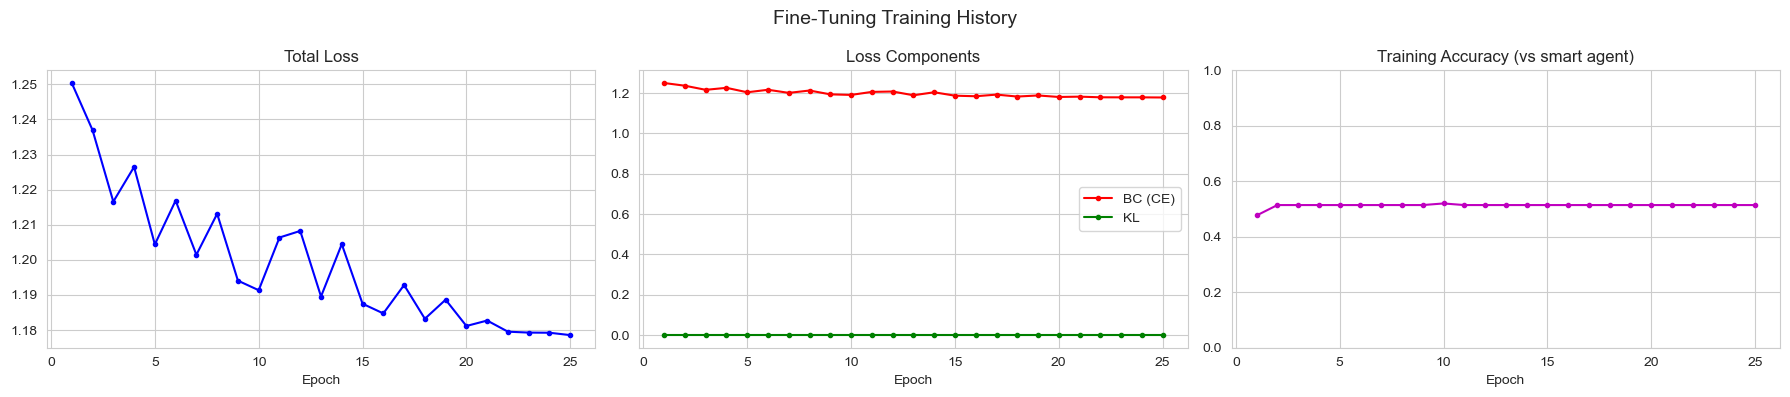

In [25]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

epochs_x = range(1, FT_EPOCHS + 1)

axes[0].plot(epochs_x, history['train_loss'], 'b-o', markersize=3)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_x, history['train_bc_loss'], 'r-o', markersize=3, label='BC (CE)')
axes[1].plot(epochs_x, history['train_kl_loss'], 'g-o', markersize=3, label='KL')
axes[1].set_title('Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs_x, history['train_acc'], 'm-o', markersize=3)
axes[2].set_title('Training Accuracy (vs smart agent)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)

plt.suptitle('Fine-Tuning Training History', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Evaluate on the Same Feedback Levels

Compare Base, Smart, and Fine-Tuned agents on the **exact same** config + seeds used for correction collection.

In [26]:
def evaluate_agent_episodes(agent, config_index, seeds, start_levels=None, name="Agent"):
    """Evaluate agent across episodes, return per-episode metrics."""
    if start_levels is None:
        start_levels = [0] * len(seeds)
    
    results = []
    for seed, level in zip(seeds, start_levels):
        env = make_env(config_index, seed=seed, start_level=level)
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        
        done, total_reward, steps = False, 0.0, 0
        actions = []
        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            action = int(action.item()) if hasattr(action, 'item') else int(action)
            actions.append(action)
            result = env.step(action)
            if len(result) == 5:
                obs, reward, terminated, truncated, info = result
                done = terminated or truncated
            else:
                obs, reward, done, info = result
            total_reward += float(reward)
            steps += 1
        env.close()
        
        ad = Counter(actions)
        results.append({
            'agent': name, 'seed': seed, 'level': level, 'config': config_index,
            'score': total_reward, 'steps': steps,
            'n_left': ad.get(0,0), 'n_stay': ad.get(1,0),
            'n_right': ad.get(2,0), 'n_throw': ad.get(3,0),
        })
    return results


# Use a subset of feedback seeds for faster eval (or all if small)
EVAL_SEEDS  = FEEDBACK_SEEDS[:20]
EVAL_LEVELS = FEEDBACK_LEVELS[:20]

print(f"Evaluating on {len(EVAL_SEEDS)} feedback levels (config={FEEDBACK_CONFIG})")
print("=" * 70)

results = []
results += evaluate_agent_episodes(base_agent, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS, "Base")
results += evaluate_agent_episodes(smart_agent, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS, "Smart (User Proxy)")
results += evaluate_agent_episodes(finetuned_agent, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS, "Fine-Tuned")

df_eval = pd.DataFrame(results)

summary = df_eval.groupby('agent')['score'].agg(['mean', 'std', 'min', 'max']).round(2)
print("\nScore Summary:")
print(summary)

# Score improvement
base_mean = df_eval[df_eval['agent']=='Base']['score'].mean()
ft_mean   = df_eval[df_eval['agent']=='Fine-Tuned']['score'].mean()
smart_mean = df_eval[df_eval['agent']=='Smart (User Proxy)']['score'].mean()

print(f"\n  Base → Fine-Tuned:  {ft_mean - base_mean:+.2f} score change")
if abs(smart_mean - base_mean) > 0.01:
    print(f"  Gap closed (towards Smart): {(ft_mean - base_mean) / (smart_mean - base_mean) * 100:.1f}%")

Evaluating on 4 feedback levels (config=1)
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebIn

## 6. Score & Action Distribution Plots

C:\Users\matan\AppData\Local\Temp\ipykernel_12432\505824305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eval, x='agent', y='score', order=agent_order, palette=colors, ax=axes[0])


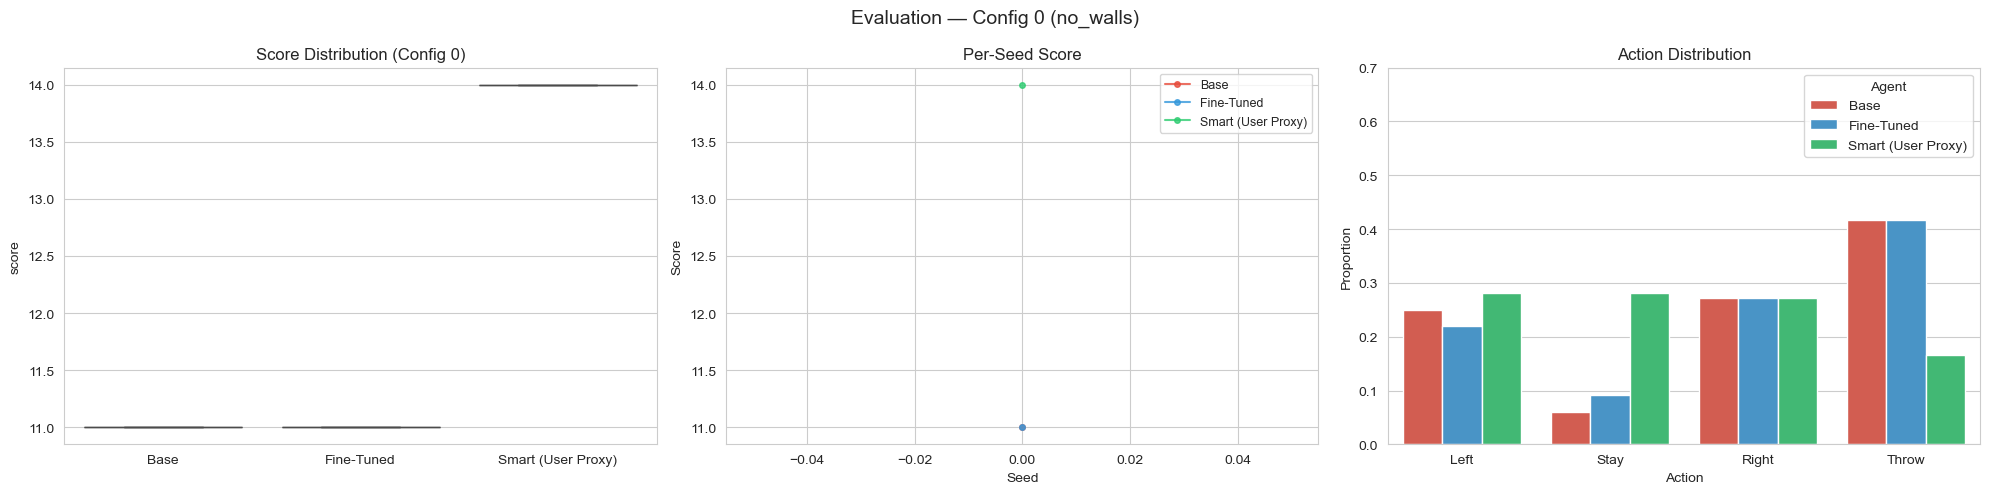

In [33]:
agent_order = ['Base', 'Fine-Tuned', 'Smart (User Proxy)']
colors = {'Base': '#e74c3c', 'Fine-Tuned': '#3498db', 'Smart (User Proxy)': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Box plot of scores
sns.boxplot(data=df_eval, x='agent', y='score', order=agent_order, palette=colors, ax=axes[0])
axes[0].set_title(f'Score Distribution (Config {FEEDBACK_CONFIG})', fontsize=12)
axes[0].set_xlabel('')

# 2) Per-seed score lines
for name in agent_order:
    sub = df_eval[df_eval['agent'] == name]
    axes[1].plot(sub['seed'].values, sub['score'].values, 'o-',
                 label=name, color=colors[name], alpha=0.8, markersize=4)
axes[1].set_title('Per-Seed Score', fontsize=12)
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)

# 3) Action distribution
action_cols = ['n_left', 'n_stay', 'n_right', 'n_throw']
action_data = []
for agent_name in agent_order:
    sub = df_eval[df_eval['agent'] == agent_name]
    totals = sub[action_cols].sum()
    total_all = totals.sum()
    for col, act in zip(action_cols, ['Left', 'Stay', 'Right', 'Throw']):
        action_data.append({'Agent': agent_name, 'Action': act, 'Proportion': totals[col] / max(total_all, 1)})

sns.barplot(data=pd.DataFrame(action_data), x='Action', y='Proportion', hue='Agent',
            hue_order=agent_order, palette=colors, ax=axes[2])
axes[2].set_title('Action Distribution', fontsize=12)
axes[2].set_ylim(0, 0.7)

plt.suptitle(f'Evaluation — Config {FEEDBACK_CONFIG} ({ENV_CONFIG_DEFINITIONS[FEEDBACK_CONFIG]["option_name"]})',
             fontsize=14)
plt.tight_layout()
plt.show()

Drawing agent paths for config=1, level=5...
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo


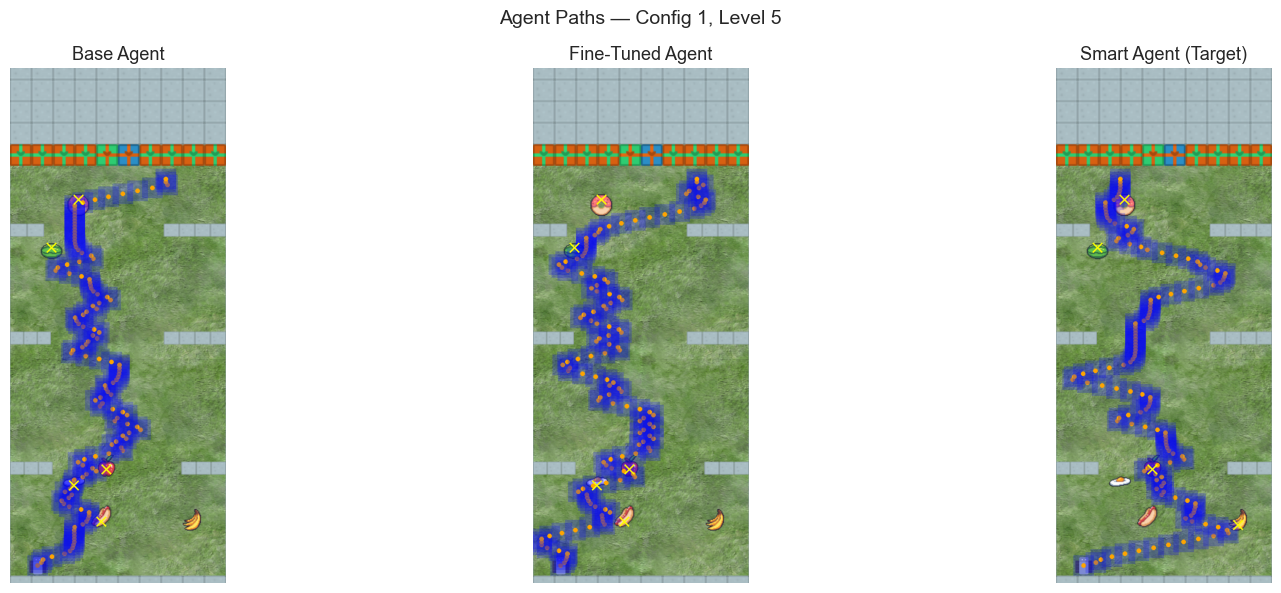

In [28]:
# --- Visual agent path comparison on a single level ---

def plot_agent_path(config_index, start_level, agent):
    """Record and draw the full agent path for one episode."""
    env = make_env(config_index, seed=0, start_level=start_level)
    frames_list, frames_indexes, collect_indexes, wall_collision_index, collisions, door_opens = \
        record_frames_with_doors(env, agent, frames_jumps=1)
    path_image, _ = draw_full_path_with_doors(
        frames_list=frames_list, frames_indexes=frames_indexes,
        collect_indexes=collect_indexes, collisions=collisions,
        frames_jumps=1, wall_collision_index=wall_collision_index,
        use_rectangle=True, door_opens=door_opens
    )
    env.close()
    return path_image

DEMO_LEVEL = 5 #FEEDBACK_LEVELS[0]
config_idx = 1
print(f"Drawing agent paths for config={config_idx}, level={DEMO_LEVEL}...")


base_path_img     = plot_agent_path(config_idx, DEMO_LEVEL, base_agent)
ft_path_img       = plot_agent_path(config_idx, DEMO_LEVEL, finetuned_agent)
smart_path_img    = plot_agent_path(config_idx, DEMO_LEVEL, smart_agent)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes, 
                           [base_path_img, ft_path_img, smart_path_img],
                           ['Base Agent', 'Fine-Tuned Agent', 'Smart Agent (Target)']):
    if img is not None:
        ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.suptitle(f'Agent Paths — Config {config_idx}, Level {DEMO_LEVEL}', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Hyperparameter Search — Maximize Agreement with Smart Agent

Grid search over `lr`, `epochs`, `kl_weight`, and `bc_weight`.  
For each combo we:
1. Clone a fresh base agent
2. Fine-tune on the **already-collected corrections** (fast — no new env rollouts)
3. Run the fine-tuned agent on a small eval set and measure **action agreement %** with the smart agent (the metric we care about)
4. Also track score and training accuracy

Since you want the fine-tuned agent to move **as close as possible** to the smart agent, we use **low or zero `kl_weight`** in the search space (less anchoring to the original).

In [ ]:
import itertools, gc

# ===================== SEARCH SPACE =====================
# We intentionally include kl_weight=0 because you don't mind
# diverging from the original base agent.

SEARCH_SPACE = {
    'lr':        [3e-4, 1e-3, 3e-3],
    'epochs':    [10, 25, 50],
    'kl_weight': [0.1, 0.3],        # 0 = pure BC, no anchoring
    'bc_weight': [1.0],              # keep fixed (CE is the main signal)
    'batch_size': [32],
}

# Quick eval: measure action agreement on a small subset of feedback levels
SEARCH_EVAL_SEEDS  = FEEDBACK_SEEDS[:10]
SEARCH_EVAL_LEVELS = FEEDBACK_LEVELS[:10]

def measure_action_agreement(agent_a, agent_b, config_index, seeds, levels):
    """Run both agents on the same episodes and return % of timesteps
    where they choose the same action (deterministic)."""
    agree = 0
    total = 0
    for seed, level in zip(seeds, levels):
        env = make_env(config_index, seed=seed, start_level=level)
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        done = False
        while not done:
            a1, _ = agent_a.predict(obs, deterministic=True)
            a2, _ = agent_b.predict(obs, deterministic=True)
            a1 = int(a1.item()) if hasattr(a1, 'item') else int(a1)
            a2 = int(a2.item()) if hasattr(a2, 'item') else int(a2)
            agree += int(a1 == a2)
            total += 1
            result = env.step(a1)
            if len(result) == 5:
                obs, reward, terminated, truncated, info = result
                done = terminated or truncated
            else:
                obs, reward, done, info = result
        env.close()
    return agree / max(total, 1), total


# ===================== RUN GRID SEARCH =====================
combos = list(itertools.product(
    SEARCH_SPACE['lr'],
    SEARCH_SPACE['epochs'],
    SEARCH_SPACE['kl_weight'],
    SEARCH_SPACE['bc_weight'],
    SEARCH_SPACE['batch_size'],
))

# Baseline: how much does the base agent already agree with the smart agent?
base_agree, _ = measure_action_agreement(
    base_agent, smart_agent, FEEDBACK_CONFIG, SEARCH_EVAL_SEEDS, SEARCH_EVAL_LEVELS)
print(f"Baseline agreement (Base vs Smart): {base_agree:.1%}")
print(f"Grid search: {len(combos)} configurations\n")
print(f"{'#':>3} | {'LR':>8} | {'Epochs':>6} | {'KL_w':>5} | {'BS':>4} | "
      f"{'Train Acc':>9} | {'Agreement':>9} | {'Δ from base':>11}")
print("-" * 85)

search_results = []

for i, (lr, epochs, kl_w, bc_w, bs) in enumerate(combos):
    # Fresh clone of base agent
    ft_model = PPO.load(BASE_AGENT_PATH)
    ds = CorrectionDataset(
        corrections_obs, corrections_user, corrections_base,
        augment=AUGMENT_DATA, aug_repeats=AUG_REPEATS,
        color_jitter=AUG_COLOR_JITTER, random_crop=AUG_RANDOM_CROP,
        horizontal_flip=AUG_HORIZONTAL_FLIP, gaussian_noise=AUG_GAUSSIAN_NOISE,
        cutout=AUG_CUTOUT,
    )

    # Fine-tune (silently)
    import io as _io, contextlib
    with contextlib.redirect_stdout(_io.StringIO()):
        hist = finetune(
            ft_model, ds,
            epochs=epochs, batch_size=bs, lr=lr,
            bc_weight=bc_w, kl_weight=kl_w,
            freeze_cnn=FREEZE_CNN,
        )

    final_acc = hist['train_acc'][-1]

    # Measure action agreement with smart agent
    agree_pct, n_steps = measure_action_agreement(
        ft_model, smart_agent, FEEDBACK_CONFIG, SEARCH_EVAL_SEEDS, SEARCH_EVAL_LEVELS)

    delta = agree_pct - base_agree

    search_results.append({
        'lr': lr, 'epochs': epochs, 'kl_weight': kl_w,
        'bc_weight': bc_w, 'batch_size': bs,
        'train_acc': final_acc,
        'smart_agreement': agree_pct,
        'delta_from_base': delta,
        'eval_steps': n_steps,
    })

    print(f"{i+1:3d} | {lr:8.1e} | {epochs:6d} | {kl_w:5.2f} | {bs:4d} | "
          f"{final_acc:9.3f} | {agree_pct:8.1%} | {delta:+10.1%}")

    # Free memory
    del ft_model, ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_search = pd.DataFrame(search_results)
print(f"\n{'='*85}")
print("GRID SEARCH COMPLETE")
print(f"{'='*85}")

Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Baseline agreement (Base vs Smart): 28.8%
Grid search: 18 configurations

  # |       LR | Epochs |  KL_w |   BS | Train Acc | Agreement | Δ from base
-------------------------------------------------------------------------------------
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
  1 |  3.0e-04 |     10 |  0.10 |   32 |     0.489 |    28.8% |      +0.0%
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
  2 |  3.0e-04 |     10 |  0.30 |   32 |     0.457 |    31.8% |      +3.0%
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
  3 |  3.0e-04 |     25 |  0.10 |   32 |     0.479 |    34.1% |      +5.3%
Using prebuilt binaries from: c:\Users\matan\master_thesis

In [36]:
# ===================== RESULTS ANALYSIS =====================

# Sort by agreement (best first)
df_sorted = df_search.sort_values('smart_agreement', ascending=False).reset_index(drop=True)
df_sorted.index += 1  # 1-based rank
df_sorted.index.name = 'Rank'

print("Top 5 Configurations (by agreement with smart agent):\n")
print(df_sorted.head(5).to_string())

best = df_sorted.iloc[0]
print(f"\n{'='*70}")
print(f"BEST CONFIG")
print(f"{'='*70}")
print(f"  LR:           {best['lr']:.1e}")
print(f"  Epochs:       {int(best['epochs'])}")
print(f"  KL weight:    {best['kl_weight']:.2f}")
print(f"  Batch size:   {int(best['batch_size'])}")
print(f"  Train acc:    {best['train_acc']:.3f}")
print(f"  Agreement:    {best['smart_agreement']:.1%}  (base was {base_agree:.1%})")
print(f"  Improvement:  {best['delta_from_base']:+.1%}")
print(f"{'='*70}")

Top 5 Configurations (by agreement with smart agent):

          lr  epochs  kl_weight  bc_weight  batch_size  train_acc  smart_agreement  delta_from_base  eval_steps
Rank                                                                                                           
1     0.0010      25        0.3        1.0          32   0.489362         0.348485         0.060606         132
2     0.0003      25        0.1        1.0          32   0.478723         0.340909         0.053030         132
3     0.0010      25        0.1        1.0          32   0.500000         0.333333         0.045455         132
4     0.0010      10        0.3        1.0          32   0.489362         0.325758         0.037879         132
5     0.0030      10        0.1        1.0          32   0.478723         0.318182         0.030303         132

BEST CONFIG
  LR:           1.0e-03
  Epochs:       25
  KL weight:    0.30
  Batch size:   32
  Train acc:    0.489
  Agreement:    34.8%  (base was 28.8%)
  I

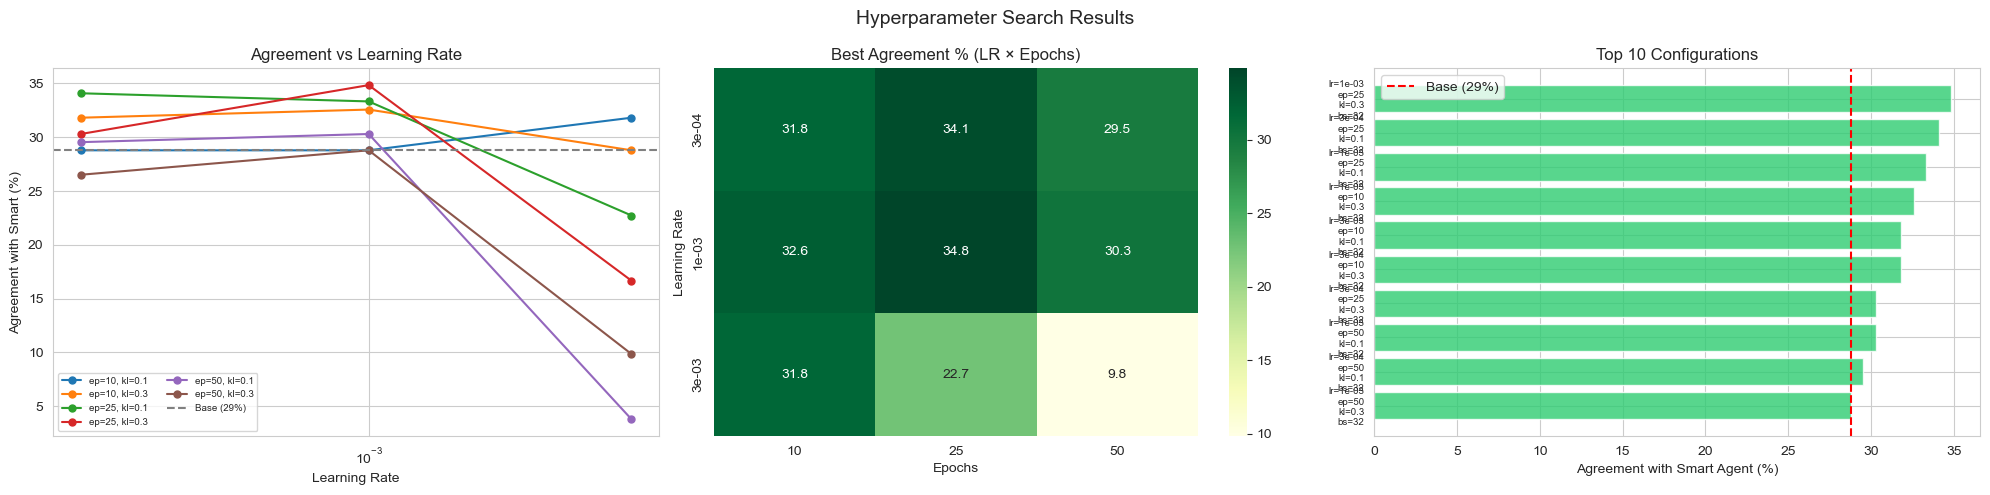

In [37]:
# ===================== VISUALIZATION =====================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Agreement vs LR (grouped by epochs)
for ep in sorted(df_search['epochs'].unique()):
    sub = df_search[df_search['epochs'] == ep]
    for kl in sorted(sub['kl_weight'].unique()):
        s = sub[sub['kl_weight'] == kl].sort_values('lr')
        label = f"ep={int(ep)}, kl={kl:.1f}"
        axes[0].plot(s['lr'], s['smart_agreement'] * 100, 'o-', label=label, markersize=5)
axes[0].axhline(base_agree * 100, ls='--', color='gray', label=f'Base ({base_agree:.0%})')
axes[0].set_xscale('log')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Agreement with Smart (%)')
axes[0].set_title('Agreement vs Learning Rate')
axes[0].legend(fontsize=7, ncol=2)

# 2) Heatmap: LR vs Epochs (best kl_weight for each combo)
# Pivot: for each (lr, epochs) take the max agreement across kl/bs
pivot = df_search.groupby(['lr', 'epochs'])['smart_agreement'].max().unstack()
sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlGn', ax=axes[1],
            xticklabels=[str(int(x)) for x in pivot.columns],
            yticklabels=[f"{x:.0e}" for x in pivot.index])
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Best Agreement % (LR × Epochs)')

# 3) Bar chart of top 10 configs
top10 = df_sorted.head(10)
labels = [f"lr={r['lr']:.0e}\nep={int(r['epochs'])}\nkl={r['kl_weight']:.1f}\nbs={int(r['batch_size'])}" 
          for _, r in top10.iterrows()]
bars = axes[2].barh(range(len(top10)), top10['smart_agreement'] * 100, color='#2ecc71', alpha=0.8)
axes[2].axvline(base_agree * 100, ls='--', color='red', label=f'Base ({base_agree:.0%})')
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(labels, fontsize=7)
axes[2].set_xlabel('Agreement with Smart Agent (%)')
axes[2].set_title('Top 10 Configurations')
axes[2].legend()
axes[2].invert_yaxis()

plt.suptitle('Hyperparameter Search Results', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Retrain with Best Config & Full Evaluation

Take the best hyperparameters from the search and retrain from scratch. Then run the full evaluation (scores, action distributions, path visualization) to confirm the fine-tuned agent truly shifted towards the smart agent.

In [ ]:
# ===================== RETRAIN WITH BEST CONFIG =====================

BEST_LR       = best['lr']
BEST_EPOCHS   = int(best['epochs'])
BEST_KL       = best['kl_weight']
BEST_BS       = int(best['batch_size'])

print(f"Retraining with best config:")
print(f"  LR={BEST_LR:.1e}, Epochs={BEST_EPOCHS}, KL={BEST_KL}, BS={BEST_BS}")
print(f"{'='*70}")

# Fresh base agent
finetuned_best = PPO.load(BASE_AGENT_PATH)
ds_best = CorrectionDataset(
    corrections_obs, corrections_user, corrections_base,
    augment=AUGMENT_DATA, aug_repeats=AUG_REPEATS,
    color_jitter=AUG_COLOR_JITTER, random_crop=AUG_RANDOM_CROP,
    horizontal_flip=AUG_HORIZONTAL_FLIP, gaussian_noise=AUG_GAUSSIAN_NOISE,
    cutout=AUG_CUTOUT,
)

history_best = finetune(
    finetuned_best, ds_best,
    epochs=BEST_EPOCHS,
    batch_size=BEST_BS,
    lr=BEST_LR,
    bc_weight=1.0,
    kl_weight=BEST_KL,
    freeze_cnn=FREEZE_CNN,
)

# Measure agreement
best_agree, _ = measure_action_agreement(
    finetuned_best, smart_agent, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS)
print(f"\nFinal agreement with smart agent: {best_agree:.1%} (base was {base_agree:.1%})")

# Full evaluation
print(f"\n{'='*70}")
print("FULL EVALUATION (best fine-tuned)")
print(f"{'='*70}")

results_best = []
results_best += evaluate_agent_episodes(base_agent, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS, "Base")
results_best += evaluate_agent_episodes(smart_agent, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS, "Smart (User Proxy)")
results_best += evaluate_agent_episodes(finetuned_best, FEEDBACK_CONFIG, EVAL_SEEDS, EVAL_LEVELS, "Fine-Tuned (Best)")

df_best = pd.DataFrame(results_best)
summary_best = df_best.groupby('agent')['score'].agg(['mean', 'std', 'min', 'max']).round(2)
print("\nScore Summary:")
print(summary_best)

b_m = df_best[df_best['agent']=='Base']['score'].mean()
f_m = df_best[df_best['agent']=='Fine-Tuned (Best)']['score'].mean()
s_m = df_best[df_best['agent']=='Smart (User Proxy)']['score'].mean()
print(f"\n  Base → Fine-Tuned (Best): {f_m - b_m:+.2f} score change")
print(f"  Agreement with smart:     {best_agree:.1%}")

Retraining with best config:
  LR=1.0e-03, Epochs=25, KL=0.3, BS=32
  Device: cuda | Samples: 94 | Epochs: 25 | BS: 32 | LR: 0.001 | BC_w: 1.0 | KL_w: 0.3
----------------------------------------------------------------------
  Epoch   1/25 | loss=1.8292 (bc=1.6902 kl=0.4634) | acc=0.255
  Epoch   3/25 | loss=1.4777 (bc=1.4154 kl=0.2078) | acc=0.394
  Epoch   6/25 | loss=1.4419 (bc=1.3892 kl=0.1757) | acc=0.277
  Epoch   9/25 | loss=1.3909 (bc=1.3543 kl=0.1220) | acc=0.362
  Epoch  12/25 | loss=1.3710 (bc=1.3193 kl=0.1722) | acc=0.457
  Epoch  15/25 | loss=1.3898 (bc=1.3051 kl=0.2825) | acc=0.362
  Epoch  18/25 | loss=1.3224 (bc=1.2742 kl=0.1605) | acc=0.489
  Epoch  21/25 | loss=1.2943 (bc=1.2427 kl=0.1721) | acc=0.500
  Epoch  24/25 | loss=1.2797 (bc=1.2337 kl=0.1534) | acc=0.489
  Epoch  25/25 | loss=1.2772 (bc=1.2303 kl=0.1563) | acc=0.489
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo

Final agreement with sm

C:\Users\matan\AppData\Local\Temp\ipykernel_12432\3641396521.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_best, x='agent', y='score', order=agent_order_best, palette=colors_best, ax=axes[0])


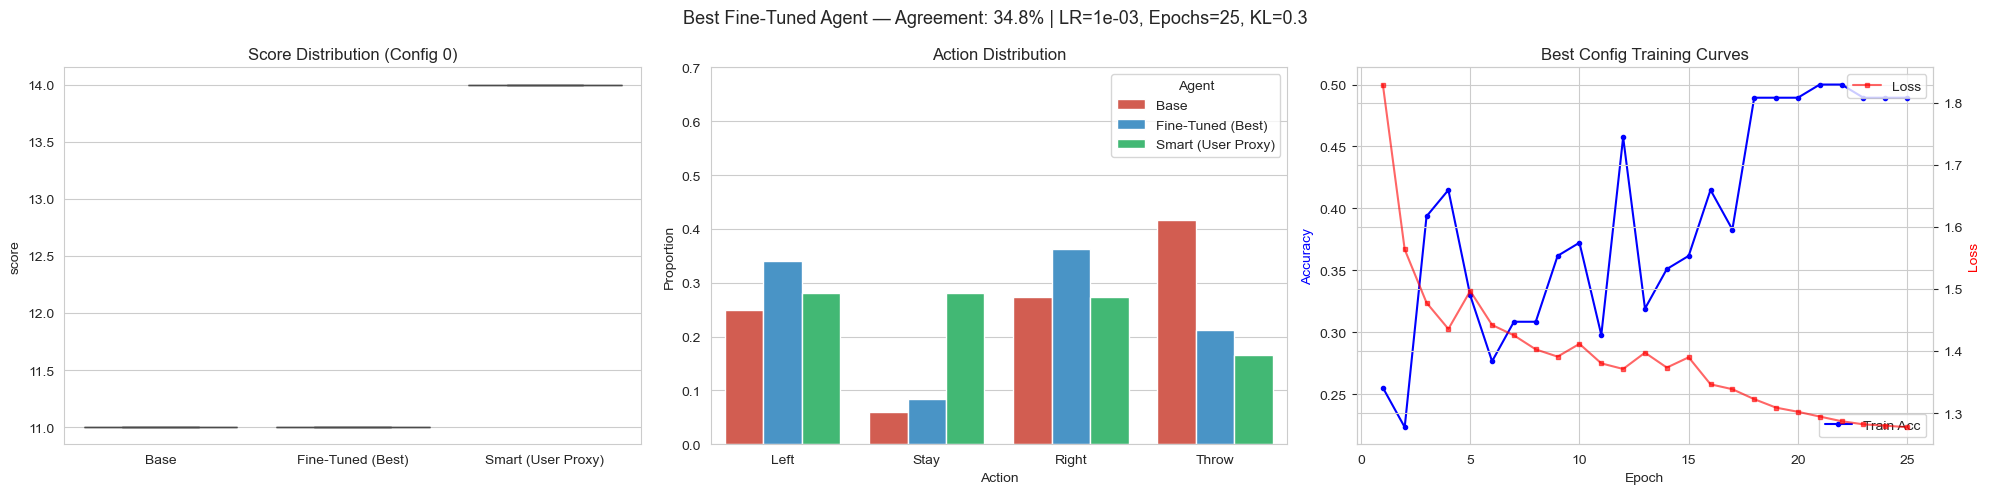


Drawing agent paths for config=0, level=10...
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo
Using prebuilt binaries from: c:\Users\matan\master_thesis\rl_envs\procgen\procgen\.build\relwithdebinfo\RelWithDebInfo


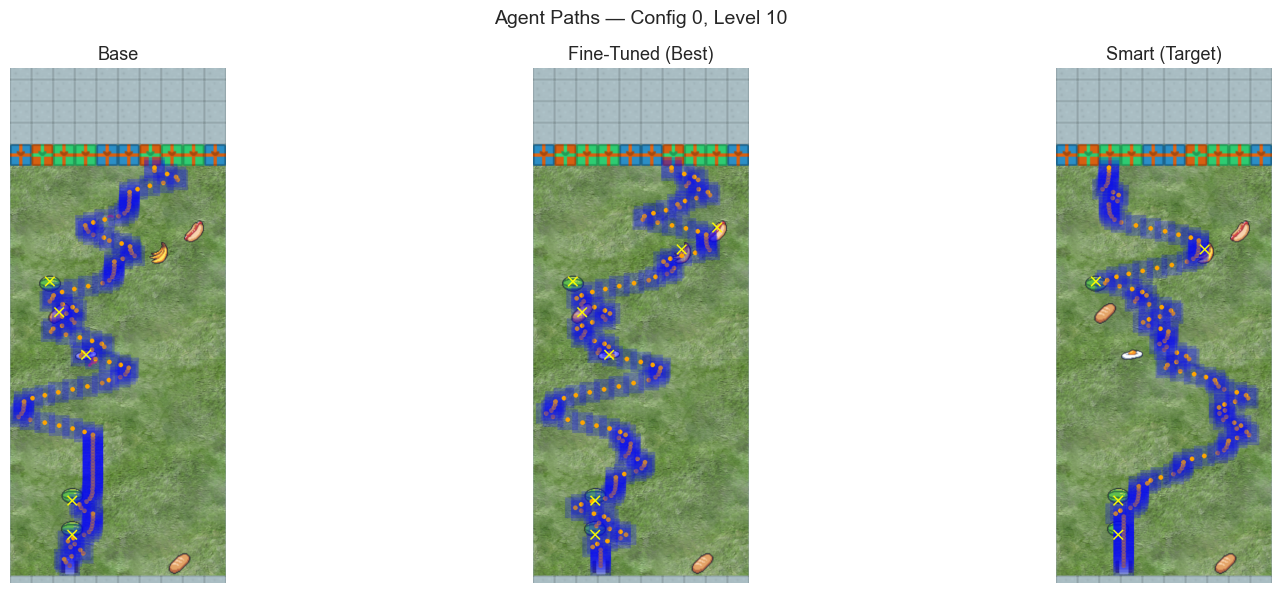

In [39]:
# ===================== FINAL COMPARISON PLOTS =====================

agent_order_best = ['Base', 'Fine-Tuned (Best)', 'Smart (User Proxy)']
colors_best = {'Base': '#e74c3c', 'Fine-Tuned (Best)': '#3498db', 'Smart (User Proxy)': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Score box plot
sns.boxplot(data=df_best, x='agent', y='score', order=agent_order_best, palette=colors_best, ax=axes[0])
axes[0].set_title(f'Score Distribution (Config {FEEDBACK_CONFIG})')
axes[0].set_xlabel('')

# 2) Action distribution
action_cols = ['n_left', 'n_stay', 'n_right', 'n_throw']
ad = []
for ag in agent_order_best:
    sub = df_best[df_best['agent'] == ag]
    tots = sub[action_cols].sum()
    t_all = tots.sum()
    for c, a in zip(action_cols, ['Left', 'Stay', 'Right', 'Throw']):
        ad.append({'Agent': ag, 'Action': a, 'Proportion': tots[c] / max(t_all, 1)})
sns.barplot(data=pd.DataFrame(ad), x='Action', y='Proportion', hue='Agent',
            hue_order=agent_order_best, palette=colors_best, ax=axes[1])
axes[1].set_title('Action Distribution')
axes[1].set_ylim(0, 0.7)

# 3) Training curves (best run)
ep_x = range(1, BEST_EPOCHS + 1)
axes[2].plot(ep_x, history_best['train_acc'], 'b-o', markersize=3, label='Train Acc')
ax2 = axes[2].twinx()
ax2.plot(ep_x, history_best['train_loss'], 'r-s', markersize=3, alpha=0.6, label='Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy', color='blue')
ax2.set_ylabel('Loss', color='red')
axes[2].set_title('Best Config Training Curves')
axes[2].legend(loc='lower right')
ax2.legend(loc='upper right')

plt.suptitle(f'Best Fine-Tuned Agent — Agreement: {best_agree:.1%} | '
             f'LR={BEST_LR:.0e}, Epochs={BEST_EPOCHS}, KL={BEST_KL}',
             fontsize=13)
plt.tight_layout()
plt.show()

# --- Path visualization ---
print(f"\nDrawing agent paths for config={FEEDBACK_CONFIG}, level={EVAL_LEVELS[0]}...")
from dpu_clf import record_frames_with_doors, draw_full_path_with_doors

def _path(agent, cfg, lvl):
    env = make_env(cfg, seed=0, start_level=lvl)
    fl, fi, ci, wci, co, do = record_frames_with_doors(env, agent, frames_jumps=1)
    img, _ = draw_full_path_with_doors(frames_list=fl, frames_indexes=fi,
        collect_indexes=ci, collisions=co, frames_jumps=1,
        wall_collision_index=wci, use_rectangle=True, door_opens=do)
    env.close()
    return img

base_p  = _path(base_agent,     FEEDBACK_CONFIG, EVAL_LEVELS[0])
best_p  = _path(finetuned_best, FEEDBACK_CONFIG, EVAL_LEVELS[0])
smart_p = _path(smart_agent,    FEEDBACK_CONFIG, EVAL_LEVELS[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes, [base_p, best_p, smart_p],
                           ['Base', 'Fine-Tuned (Best)', 'Smart (Target)']):
    if img is not None:
        ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis('off')
plt.suptitle(f'Agent Paths — Config {FEEDBACK_CONFIG}, Level {EVAL_LEVELS[0]}', fontsize=14)
plt.tight_layout()
plt.show()

## Plot Levels to improved

Using progress file: c:\Users\matan\master_thesis\rl_envs\procgen\train_env\finetuned_models\progress_levels_20260310-125732\progress_eval.csv


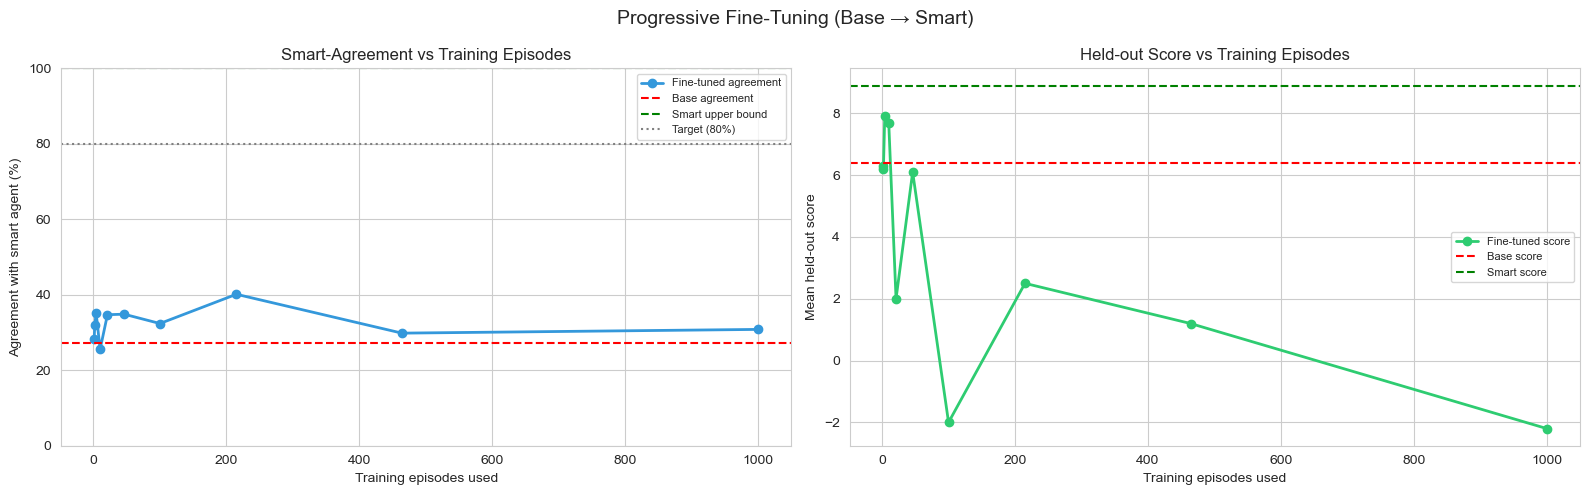


Summary table:


,checkpoint_index,episodes_used,samples_used,train_acc,heldout_score,heldout_smart_agreement
0,1,1,57,0.473684,6.3,0.283052
1,2,2,100,0.400000,6.2,0.319457
2,3,4,291,0.350515,7.9,0.351931
3,4,10,727,0.275103,7.7,0.255455
4,5,21,1589,0.375708,2.0,0.347191
5,6,46,3595,0.409179,6.1,0.348646
6,7,100,7764,0.397218,-2.0,0.323894
7,8,215,16593,0.397396,2.5,0.401408
8,9,464,35606,0.388614,1.2,0.298387
9,10,1000,75191,0.381136,-2.2,0.308285



Target 80% agreement was not reached.


In [3]:
 # --- Plot progressive fine-tuning results (from finetune_levels_progress.py) ---
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Option A: set a specific CSV path
# PROGRESS_CSV = PROJECT_ROOT / 'train_env/finetuned_models/<run_name>/progress_eval.csv'
# Option B (default): auto-pick latest progress_eval.csv
if 'PROGRESS_CSV' not in globals() or PROGRESS_CSV is None:
    candidates = sorted(
        (PROJECT_ROOT / 'train_env' / 'finetuned_models').glob('**/progress_eval.csv'),
        key=lambda p: p.stat().st_mtime
    )
    if len(candidates) == 0:
        raise FileNotFoundError(
            'No progress_eval.csv found. Run train_env/finetune_levels_progress.py first.'
        )
    PROGRESS_CSV = candidates[-1]

print(f'Using progress file: {PROGRESS_CSV}')
df_prog = pd.read_csv(PROGRESS_CSV).sort_values('episodes_used').reset_index(drop=True)

# Optional target agreement threshold
TARGET_AGREEMENT = 0.80

# Find first checkpoint reaching target
hit = df_prog[df_prog['heldout_smart_agreement'] >= TARGET_AGREEMENT]
first_hit = hit.iloc[0] if len(hit) > 0 else None

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Agreement vs episodes used
axes[0].plot(
    df_prog['episodes_used'],
    df_prog['heldout_smart_agreement'] * 100,
    marker='o',
    linewidth=2,
    color='#3498db',
    label='Fine-tuned agreement'
 )
axes[0].axhline(df_prog['base_smart_agreement'].iloc[0] * 100, linestyle='--', color='red', label='Base agreement')
axes[0].axhline(df_prog['smart_smart_agreement'].iloc[0] * 100, linestyle='--', color='green', label='Smart upper bound')
axes[0].axhline(TARGET_AGREEMENT * 100, linestyle=':', color='gray', label=f'Target ({TARGET_AGREEMENT:.0%})')

if first_hit is not None:
    axes[0].axvline(first_hit['episodes_used'], linestyle=':', color='purple')
    axes[0].scatter([first_hit['episodes_used']], [first_hit['heldout_smart_agreement'] * 100], color='purple', zorder=5)
    axes[0].annotate(
        f"First ≥ {TARGET_AGREEMENT:.0%}: {int(first_hit['episodes_used'])} eps",
        (first_hit['episodes_used'], first_hit['heldout_smart_agreement'] * 100),
        textcoords='offset points',
        xytext=(8, 10),
        fontsize=9,
        color='purple'
    )

axes[0].set_title('Smart-Agreement vs Training Episodes')
axes[0].set_xlabel('Training episodes used')
axes[0].set_ylabel('Agreement with smart agent (%)')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8)

# 2) Held-out score vs episodes used
axes[1].plot(
    df_prog['episodes_used'],
    df_prog['heldout_score'],
    marker='o',
    linewidth=2,
    color='#2ecc71',
    label='Fine-tuned score'
 )
axes[1].axhline(df_prog['base_score'].iloc[0], linestyle='--', color='red', label='Base score')
axes[1].axhline(df_prog['smart_score'].iloc[0], linestyle='--', color='green', label='Smart score')
axes[1].set_title('Held-out Score vs Training Episodes')
axes[1].set_xlabel('Training episodes used')
axes[1].set_ylabel('Mean held-out score')
axes[1].legend(fontsize=8)

plt.suptitle('Progressive Fine-Tuning (Base → Smart)', fontsize=14)
plt.tight_layout()
plt.show()

print('\nSummary table:')
display(df_prog[['checkpoint_index','episodes_used','samples_used','train_acc','heldout_score','heldout_smart_agreement']])

if first_hit is None:
    print(f"\nTarget {TARGET_AGREEMENT:.0%} agreement was not reached.")
else:
    print(
        f"\nReached {TARGET_AGREEMENT:.0%} agreement at checkpoint {int(first_hit['checkpoint_index'])} "
        f"after {int(first_hit['episodes_used'])} training episodes "
        f"({int(first_hit['samples_used'])} correction samples)."
    )